# EDA on 2 datasets

##### TODO
Add
- LSA explainable variance
- min_df, max_df justification 

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer

from rital_nlp_project.common.utils import load_clean_data, load_movies, load_pres
from rital_nlp_project.common.notebook_utils import init_notebook
import rital_nlp_project.common.eda as eda
from rital_nlp_project.presidents.utils import concat_seq_by_class

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
texts_movies, _ = load_movies("../Dataset/movies1000/")
texts_pres, _= load_pres("../Dataset/presidents.utf8")

In [4]:
texts_movies, classes_movies = load_clean_data("../Dataset/movies_clean_bert.parquet")
texts_movies

['bad . bad . \nbad . \nthat one word seems to pretty much sums up beyond the valley of the dolls . \nif that summary isn\'t enough for you , how about t&a , t&a , t&a ? \nstill haven\'t got the point ? \nother than director russ meyer\'s predilection for casting attractive large breasted women who ultimately expose the afore-mentioned anatomical areas , there is really only one other reason to recommend even taking a look at this movie . \nthat is the fact that it was co-written by famed film critic roger ebert , who also was responsible for the screenplay . \nafter watching this movie you will never be able to sit through another one of his reviews where he gives a movie a thumbs down for bad writing with a straight face . \nthis movie stinks out loud . \nquite frankly , this movie deserves a . \nbut there are parts of it that are so bad they are almost funny . \nso i\'m giving it a . \nand maybe that is too generous . \nright from the opening credits , i knew that i had a class-a bo

In [6]:
texts_movies, classes_movies = load_clean_data("../Dataset/movies_clean.parquet")
texts_pres, classes_pres = load_clean_data("../Dataset/presidents_clean.parquet")
texts_pres_concat, classes_pres_concat = concat_seq_by_class(texts_pres, classes_pres, n=20)

print(len(classes_movies), len(classes_pres), len(classes_pres_concat))

labels = ["Movies dataset", "Presidents dataset", "Presidents dataset concatenated"] # for plots

2000 57413 3224


Movies classes ratio: 1.0
Presidents classes ratio: 6.631662900438655
Presidents classes ratio: 4.8939670932358315


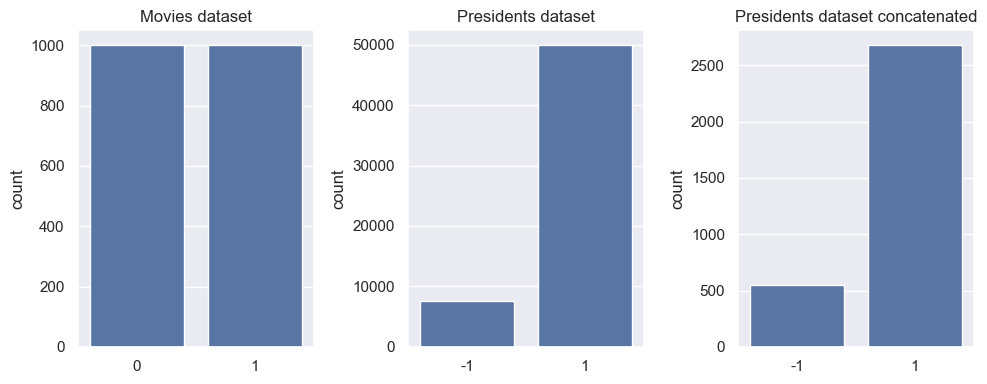

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))
sns.countplot(x=classes_movies, ax=ax1)
sns.countplot(x=classes_pres, ax=ax2)
sns.countplot(x=classes_pres_concat, ax=ax3)

ax1.set_title(labels[0])
ax2.set_title(labels[1])
ax3.set_title(labels[2])

plt.tight_layout()

_, counts= np.unique(classes_movies, return_counts=True)
print("Movies classes ratio:", counts[0]/counts[1])

_, counts= np.unique(classes_pres, return_counts=True)
print("Presidents classes ratio:", counts[1]/counts[0])

_, counts= np.unique(classes_pres_concat, return_counts=True)
print("Presidents classes ratio:", counts[1]/counts[0])

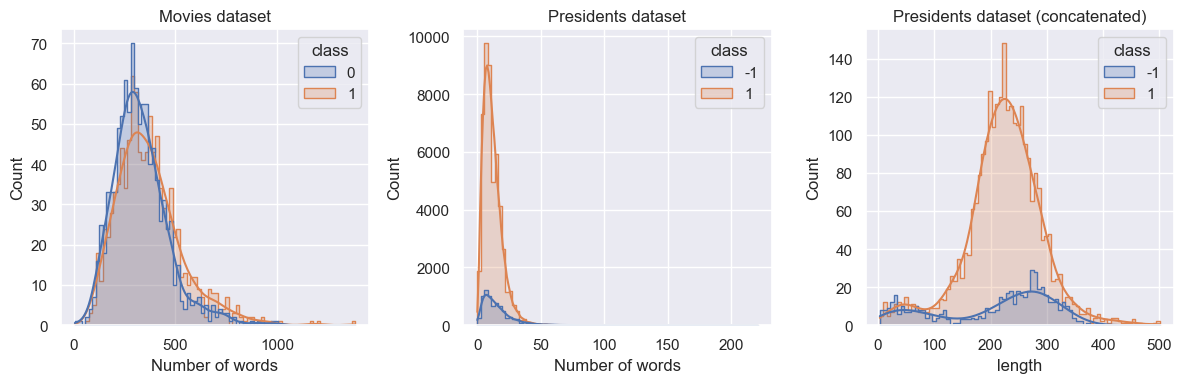

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

df_movies = pd.DataFrame(data={"length": [len(text.split()) for text in texts_movies], "class": classes_movies})
df_pres = pd.DataFrame(data={"length": [len(text.split()) for text in texts_pres], "class": classes_pres})
df_pres_concat = pd.DataFrame(data={"length": [len(text.split()) for text in texts_pres_concat], "class": classes_pres_concat})

sns.histplot(data=df_movies, x="length", hue="class", ax=ax1, bins=80, kde=True, common_bins=True, common_norm=False, element="step")
sns.histplot(data=df_pres, x="length", hue="class", ax=ax2, bins=80, kde=True, common_bins=True, common_norm=False, element="step", palette="deep")
sns.histplot(data=df_pres_concat, x="length", hue="class", ax=ax3, bins=80, kde=True, common_bins=True, common_norm=False, element="step", palette="deep")

ax1.set_title(labels[0])
ax2.set_title(labels[1])
ax3.set_title("Presidents dataset (concatenated)")

ax1.set_xlabel("Number of words")
ax2.set_xlabel("Number of words")

plt.tight_layout()

fig.savefig("plots/docs_legnth.pdf", bbox_inches="tight", format="pdf")

In [24]:
print(df_pres_concat[df_pres_concat["class"] == -1]["length"].mean(), df_pres[df_pres["class"] == -1]["length"].mean())
print(df_pres_concat[df_pres_concat["class"] == 1]["length"].mean(), df_pres[df_pres["class"] == 1]["length"].mean())

207.21572212065814 15.066728698657451
222.65857302951065 11.947424333533775


10628
7298


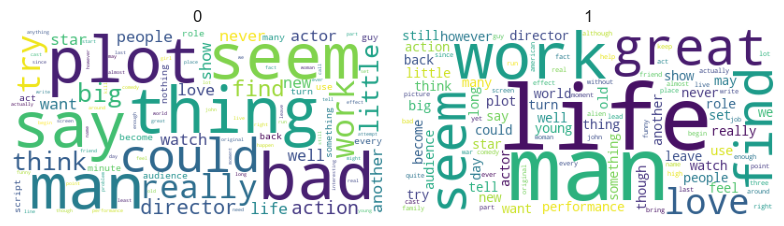

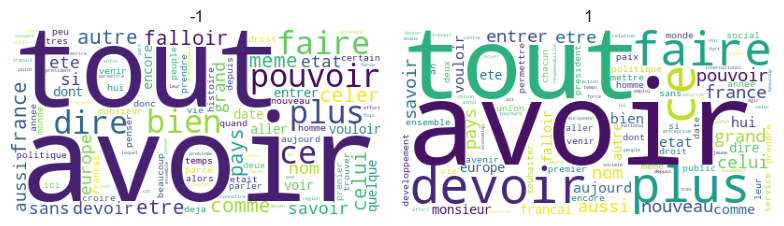

In [8]:
vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(1, 1), analyzer="word").fit(texts_movies)
matrix = vectorizer.transform(texts_movies)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_movies, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(1, 1), analyzer="word").fit(texts_pres)
matrix = vectorizer.transform(texts_pres)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_pres, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

11331
17322


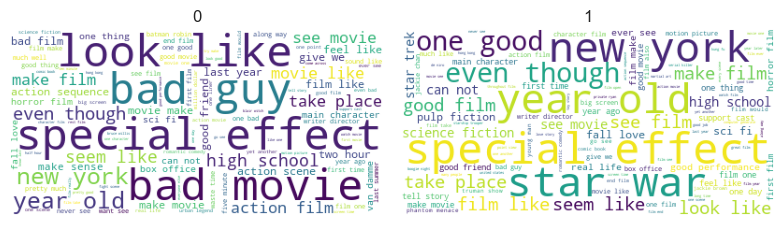

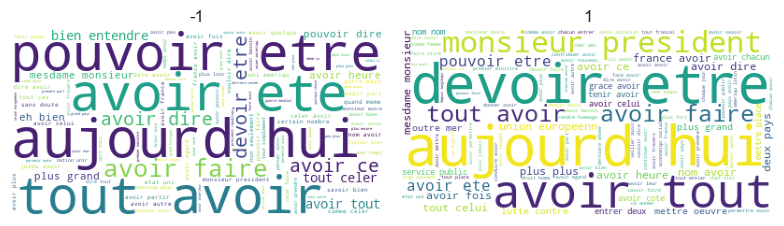

In [9]:
vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(2, 2), analyzer="word").fit(texts_movies)
matrix = vectorizer.transform(texts_movies)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_movies, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(2, 2), analyzer="word").fit(texts_pres)
matrix = vectorizer.transform(texts_pres)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_pres, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

716
3384


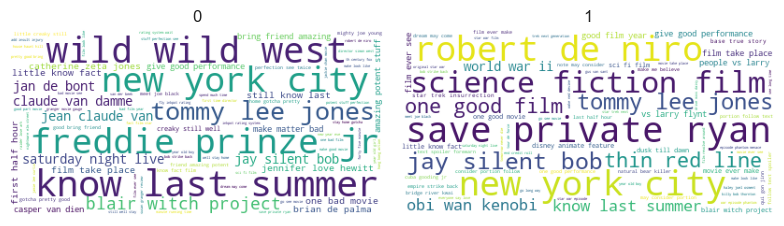

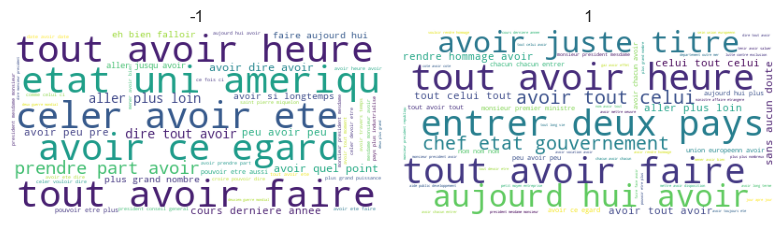

In [10]:
vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(3, 3), analyzer="word").fit(texts_movies)
matrix = vectorizer.transform(texts_movies)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_movies, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

vectorizer = CountVectorizer(min_df=5, max_df=0.5, ngram_range=(3, 3), analyzer="word").fit(texts_pres)
matrix = vectorizer.transform(texts_pres)
vocab = vectorizer.get_feature_names_out()
eda.plot_class_wordclouds(classes_pres, matrix, vocab)
print(len(vectorizer.get_feature_names_out()))

### Zipf law

In [9]:
vec_movies = CountVectorizer(min_df=20, max_df=0.5, ngram_range=(1, 1), analyzer="word")
matrix_movies = vec_movies.fit_transform(texts_movies)
vocab_movies = vec_movies.get_feature_names_out()

vec_pres = CountVectorizer(min_df=20, max_df=0.5, ngram_range=(1, 1), analyzer="word")
matrix_pres = vec_pres.fit_transform(texts_pres)
vocab_pres = vec_pres.get_feature_names_out()

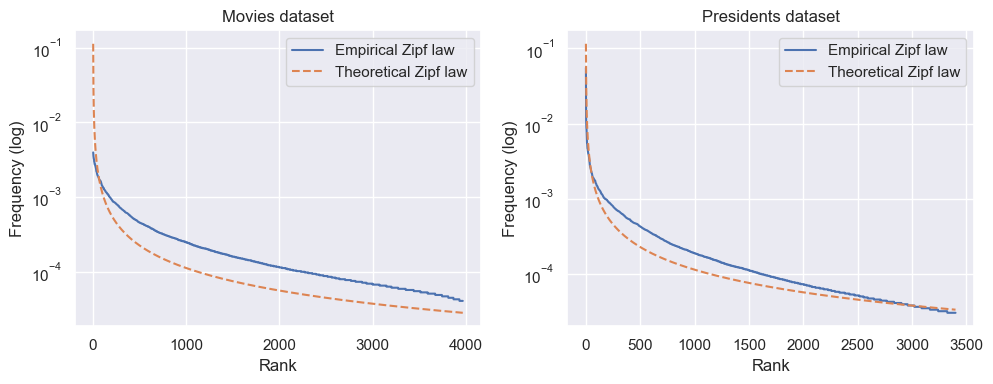

In [10]:
# Movies
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, (matrix, vocab) in enumerate([(matrix_movies, vocab_movies),
                                  (matrix_pres, vocab_pres)]):

    theo_zipf, ranks = eda.get_theo_zipf(matrix, vocab)
    emp_zipf, _ = eda.get_emp_zipf(matrix, vocab)

    axes[i].plot(ranks, emp_zipf, label="Empirical Zipf law")
    axes[i].plot(ranks, theo_zipf, linestyle="--", label="Theoretical Zipf law")
    axes[i].set_yscale("log")
    axes[i].set_title(labels[i])
    axes[i].set_xlabel("Rank")
    axes[i].set_ylabel("Frequency (log)")
    axes[i].legend()

plt.tight_layout()

### Log-odds ratio

In [38]:
vec_movies = CountVectorizer(max_df=0.8, ngram_range=(1, 2), analyzer="word", max_features=5000)
matrix_movies = vec_movies.fit_transform(texts_movies)
vocab_movies = vec_movies.get_feature_names_out()

vec_pres = CountVectorizer(max_df=0.8, ngram_range=(1, 2), analyzer="word", max_features=5000)
matrix_pres = vec_pres.fit_transform(texts_pres)
vocab_pres = vec_pres.get_feature_names_out()

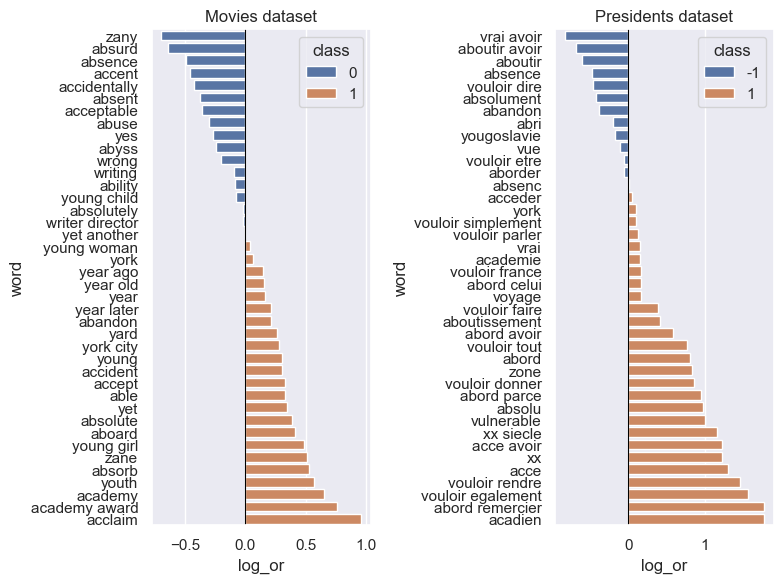

In [40]:
vals_movies = [1, 0]
df_or_movies = eda.get_log_odds_ratio(matrix_movies, vocab_movies, classes_movies, vals_movies)

vals_pres = [1, -1]
df_or_pres = eda.get_log_odds_ratio(matrix_pres, vocab_pres, classes_pres, vals_pres)

limit = 20

fig, axes = plt.subplots(1, 2, figsize=(8, 6))

for i, (df, classes_vals) in enumerate([(df_or_movies, vals_movies),
                                        (df_or_pres, vals_pres)]):
    
    df_or_top = pd.concat([df.head(limit), df.tail(limit)])
    df_or_top["class"] = np.where(df_or_top["log_or"] > 0, classes_vals[0], classes_vals[-1])
    df_or_top = df_or_top.sort_values("log_or")

    sns.barplot(data=df_or_top, x="log_or", y="word", hue="class", ax=axes[i], palette="deep")
    axes[i].set_title(labels[i])
    axes[i].axvline(0, color="black", linewidth=0.8)
        
plt.tight_layout()